### Data Dependencies

In [104]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily) # smote
library(janitor)     # data cleaning
library(tidyverse) 
library(randomForest)
library(xgboost)

### Cleaning Data 

In [ ]:
drop_redundant_yn_features <- function(df) {
  # Get all column names
  cols <- names(df)
  
  # Find Yes/No pairs by stripping the suffix
  # Pattern: variable name ends in " - Yes" or " - No"
  yes_cols <- cols[grepl("_yes$", cols)]
  no_cols  <- cols[grepl("_no$",  cols)]
  
  # Get base names for each
  yes_bases <- sub("_yes$", "", yes_cols)
  no_bases  <- sub("_no$",  "", no_cols)
  
  # Find bases that have BOTH a Yes and No column
  paired_bases <- intersect(yes_bases, no_bases)
  
  cols_to_drop <- c()
  
  for (base in paired_bases) {
    yes_col <- yes_cols[yes_bases == base]
    no_col  <- no_cols[no_bases == base]
    
    # Count NAs in each
    yes_nas <- sum(is.na(df[[yes_col]]))
    no_nas  <- sum(is.na(df[[no_col]]))
    
    # Drop whichever has more NAs; if tied, drop "No" (keep "Yes")
    if (no_nas >= yes_nas) {
      cols_to_drop <- c(cols_to_drop, no_col)
    } else {
      cols_to_drop <- c(cols_to_drop, yes_col)
    }
  }
  
  cat("Dropping", length(cols_to_drop), "redundant columns:\n")
  #cat(paste(" ", cols_to_drop), sep = "\n")
  
  df[, !names(df) %in% cols_to_drop]
}

In [105]:
set.seed(100) # Set seed

# Load & Clean Column Names
merged <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> 
  clean_names()

merged <- drop_redundant_yn_features(merged)

# Train/test split 
index <- createDataPartition(merged$outbreak , p = 0.75, list = FALSE)
train <- merged[index, ]
test  <- merged[-index, ]

# Drop county and NA columns 
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

# Ensure all columns are numeric 
non_num <- names(train)[!sapply(train, is.numeric)]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

# Mirror same cleaning on test set 
test <- test[, names(test) %in% c(names(train), "outbreak")]

non_num_test <- names(test)[!sapply(test, is.numeric) & names(test) != "outbreak"]
if (length(non_num_test) > 0) {
  test[non_num_test] <- lapply(test[non_num_test], as.numeric)
}

test$outbreak <- as.numeric(test$outbreak)

stopifnot(sum(is.na(test)) == 0)

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Test rows:",  nrow(test),  "| Cols:", ncol(test),  "\n")

# Export to csv
write_csv(train, "data/created/train_clean.csv")
write_csv(test,  "data/created/test_clean.csv")

Train rows: 191 | Cols: 220 
Test rows: 63 | Cols: 220 


### SMOGN (IN PYTHON RUN DIFFERENT KERNEL)

In [1]:
import numpy as np
import pandas as pd
import smogn
import random

# Load cleaned train data from R 
train = pd.read_csv("data/created/train_clean.csv")
train = train.sort_values(train.columns.tolist()).reset_index(drop=True)

# Apply SMOGN with manual relevance control points 
# rel_ctrl_pts_rg format: [[x, y, derivative], ...]
# x = outbreak value, y = relevance (0 = common, 1 = rare)
# Set low outbreak counts as common (0) and high counts as rare (1)

outbreak_min = train["outbreak"].min()
outbreak_max = train["outbreak"].max()
outbreak_mid = train["outbreak"].median()
outbreak_nonzero_min = train[train["outbreak"] > 0]["outbreak"].min()

# Ensure control points are strictly increasing and unique
# rel_ctrl_pts = [
#     [outbreak_min,        0, 0],   # 0 = common
#     [outbreak_nonzero_min, 0.5, 0], # first nonzero = starting to get rare
#     [outbreak_max,        1, 0],   # max = rarest, oversample most
# ]

rel_ctrl_pts = [
    [0,        0, 0],   
    [2,        1, 0]
]

randomseed = 100

np.random.seed(randomseed)
random.seed(randomseed)

train_balanced = smogn.smoter(
    data            = train,
    y               = "outbreak",
    k               = 5,
    samp_method     = "balance",
    seed            = randomseed,
    rel_thres       = 0.5,
    rel_method      = "manual",
    rel_ctrl_pts_rg = rel_ctrl_pts
)

# print("\nOutbreak distribution after SMOGN:")
# print(train_balanced["outbreak"].value_counts().sort_index())
# print("Train balanced shape:", train_balanced.shape)

print(pd.cut(train_balanced["outbreak"], bins=[-0.1, 0, 1, 2, 5, 10, np.inf]).value_counts().sort_index())

# ── 4. Export balanced train set back for R modeling ──────────────────────
train_balanced.to_csv("data/created/train_balanced.csv", index=False)

r_index: 100%|##########| 18/18 [00:00<00:00, 118.61it/s]


outbreak
(-0.1, 0.0]    74
(0.0, 1.0]     42
(1.0, 2.0]      4
(2.0, 5.0]     15
(5.0, 10.0]     6
(10.0, inf]    24
Name: count, dtype: int64


### Regular Regression Tree (No optimization)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 6.8314 
MAE  (Mean Absolute Error)    : 2.61 
R-squared                     : 0.2117 


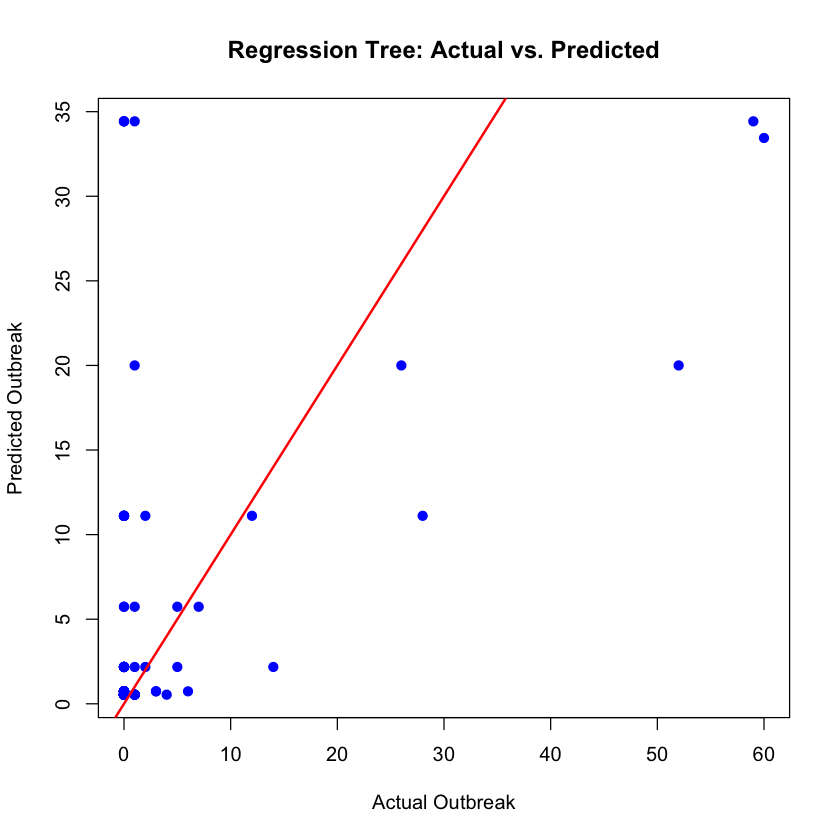

In [21]:
# Read data form CSV
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE) 
test  <- read_csv("data/created/test_clean.csv", show_col_types = FALSE) 

# Train model 
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "anova")
#rpart.plot(dtree_model)

# Eval Performance
predictions <- predict(dtree_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
dtree_rmse <- sqrt(mean((actual_values - predictions)^2))
dtree_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
dtree_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(dtree_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)    :", round(dtree_mae, 4), "\n")
cat("R-squared                     :", round(dtree_r2, 4), "\n")

# Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree: Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line


### Random Forest (No optimization)

In [22]:
# Train Model
rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

predictions <- predict(rforest_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
rforest_rmse <- sqrt(mean((actual_values - predictions)^2))
rforest_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
rforest_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(rforest_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)   :", round(rforest_mae, 4), "\n")
cat("R-squared                    :", round(rforest_r2, 4), "\n")

#Visualize predictions vs actuals
# plot(actual_values, predictions, 
#      main = "Regression Tree (Random Forest): Actual vs. Predicted", 
#      xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
#      pch = 19, col = "blue")
# abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 6.1117 
MAE  (Mean Absolute Error)   : 2.5394 
R-squared                    : 0.369 


### Boosted Tree (No optimization)

Regression Tree Accuracy Metrics (Original Train):
RMSE: 6.6077 
MAE : 1.9426 
R-squared : 0.2625 


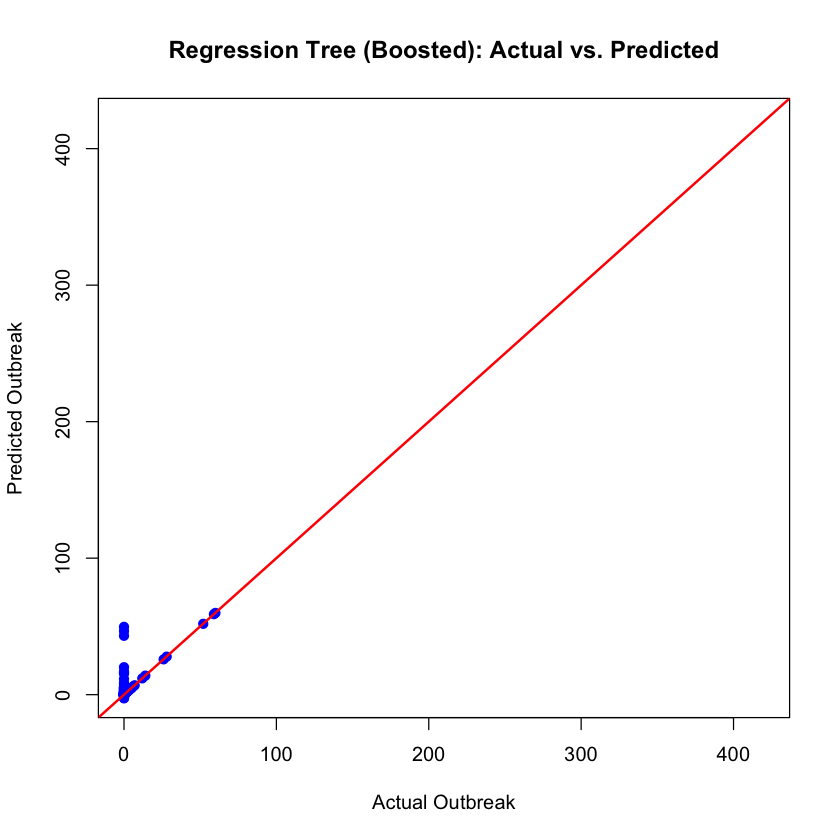

In [23]:
# 1. Prepare data
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

# Prepare the original data for prediction
# Note: ogtrain should be a DMatrix so xgboost can read it
X_og <- as.matrix(train[, names(train) != "outbreak"])
ogtrain <- xgb.DMatrix(data = X_og) 

# 2. Train the model
boost_model <- xgb.train(
  params = list(
    objective = "reg:squarederror",
    max_depth = 3,
    eta = 0.1
  ),
  data = dtrain,
  nrounds = 500
)

# 3. Predict on the ORIGINAL training set
predictions <- predict(boost_model, ogtrain) # Use dogtrain, not dtrain
actual_values <- as.numeric(as.character(train$outbreak)) # Pull from original 'train' dataframe

# 4. Calculate metrics (dimensions now match)
boost_rmse <- sqrt(mean((actual_values - predictions)^2))
boost_mae <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
boost_r2 <- 1 - (rss / tss)

# Print results
cat("Regression Tree Accuracy Metrics (Original Train):\n")
cat("RMSE:", round(boost_rmse, 4), "\n")
cat("MAE :", round(boost_mae, 4), "\n")
cat("R-squared :", round(boost_r2, 4), "\n")

# #Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree (Boosted): Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     xlim = c(0, 420), ylim = c(0, 420),
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

# TUNING SECTION

### Setting up all parameters

In [24]:
# classification tree related
maxdepths <- seq(1, 10, by = 1)
# random forest related
mtrys   <- c(seq(2, 50, by=2))
ntrees   <- c(seq(300, 700, by=50))
# XGBoost related
param_grid <- expand.grid( # tuning grid
  max_depth = c(seq(3, 9, by=2)),
  eta = c(0.01,seq(0.05, 0.4, by=0.05))
)

# Folds for cross validation
set.seed(4)

folds <- createFolds(train_balanced$outbreak, k = 10)

### Basic Regression Tree Optimization

maxdepth,cp,RMSE,MAE,R2
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.18871587,13.71812,8.850635,-0.043314068
2,0.18871587,13.88743,8.667511,-0.052106497
3,0.06851418,13.48835,8.005994,0.022041058
4,0.00321623,13.00854,7.600845,0.058246456
5,0.07204678,14.07930,8.226037,-0.072582559
6,0.07204678,13.54289,7.751721,0.007402735
7,0.10117590,12.83377,7.547774,0.096764431
8,0.07204678,13.88536,8.205649,-0.051583085
9,0.10117590,12.61690,7.694955,0.089329281


  maxdepth        cp     RMSE      MAE         R2
7        7 0.1011759 12.83377 7.547774 0.09676443


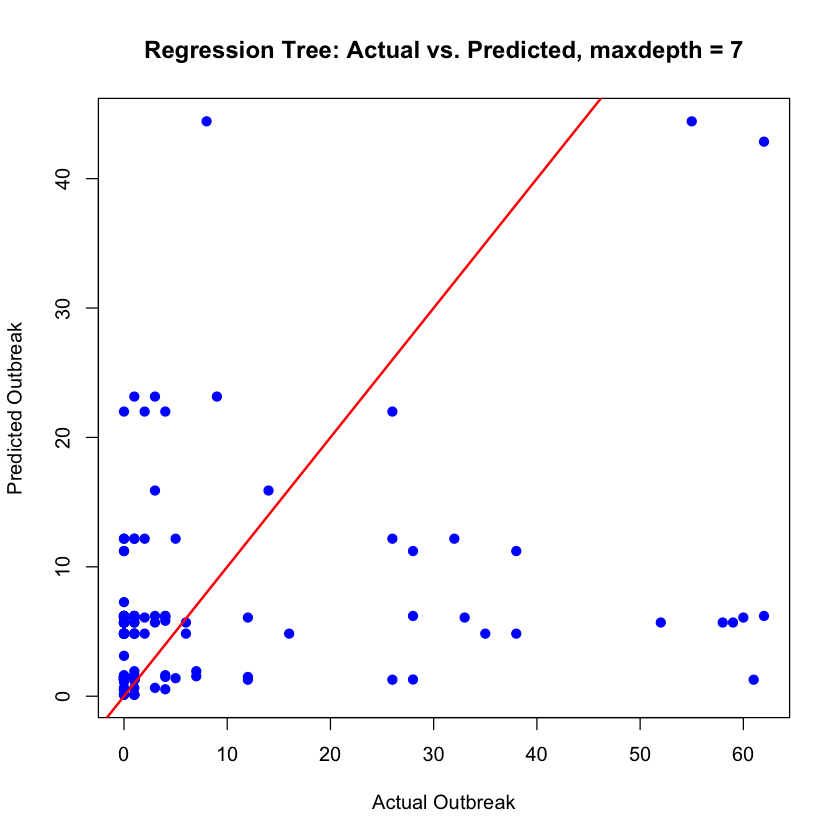

In [8]:
set.seed(100)
results <- data.frame()
pred_plot_data <- list()

for(i in maxdepths){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  depth_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    mod <- rpart(outbreak ~ .,
                 data    = fold_train,
                 method  = "anova",
                 #weights = ceiling(fold_train$population),
                 control = rpart.control(maxdepth = i, cp = -1))

    cp_table <- mod$cptable
    opt_cp   <- as.numeric(cp_table[which.min(cp_table[, "xerror"]), "CP"])[1]
    pruned   <- prune(mod, cp = opt_cp)

    predictions   <- predict(pruned, newdata = fold_test)
    actual_values <- fold_test$outbreak

    depth_predictions <- rbind(depth_predictions, data.frame(
      actual    = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  pred_plot_data[[as.character(i)]] <- depth_predictions

  results <- rbind(results, data.frame(
    maxdepth      = i,
    cp            = opt_cp,
    RMSE          = mean(fold_rmse, na.rm = TRUE),
    MAE           = mean(fold_mae,  na.rm = TRUE),
    R2            = mean(fold_r2,   na.rm = TRUE)
  ))
}

results
best_clas <- results[which.max(results$R2), ]
print(best_clas)

best_depth     <- best_clas$maxdepth[1]
best_plot_data <- pred_plot_data[[as.character(best_depth)]]

plot(best_plot_data$actual, best_plot_data$predicted,
     main = paste("Regression Tree: Actual vs. Predicted, maxdepth =", best_depth),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch  = 19,
     col  = "blue")

abline(0, 1, col = "red", lwd = 2)

### Random Forest Optimization

In [9]:
results_rf <- data.frame()
pred_plot_data_rf <- list()

set.seed(100)
for(m in mtrys){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  mtry_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    rf <- randomForest(outbreak ~ .,
                       data       = fold_train,
                       mtry       = m,
                       ntree      = 500,
                       importance = TRUE)

    predictions   <- predict(rf, newdata = fold_test)
    actual_values <- fold_test$outbreak

    mtry_predictions <- rbind(mtry_predictions, data.frame(
      actual = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae, mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  pred_plot_data_rf[[as.character(m)]] <- mtry_predictions

  results_rf <- rbind(results_rf, data.frame(
    mtry = m,
    RMSE = mean(fold_rmse, na.rm = TRUE),
    MAE  = mean(fold_mae,  na.rm = TRUE),
    R2   = mean(fold_r2,   na.rm = TRUE)
  ))
}

best_rf <- results_rf[which.max(results_rf$R2), ]
print(best_rf)

best_mtry <- best_rf$mtry[1]
best_plot_data_rf <- pred_plot_data_rf[[as.character(best_mtry)]]

plot(best_plot_data_rf$actual, best_plot_data_rf$predicted,
     main = paste("Random Forest: Actual vs. Predicted, mtry =", best_mtry),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch = 19,
     col = "blue")

abline(0, 1, col = "red", lwd = 2)

### XGBoost Optimization

   max_depth  eta     RMSE      MAE         R2
29         3 0.35 28.69735 11.91049 -0.7392607


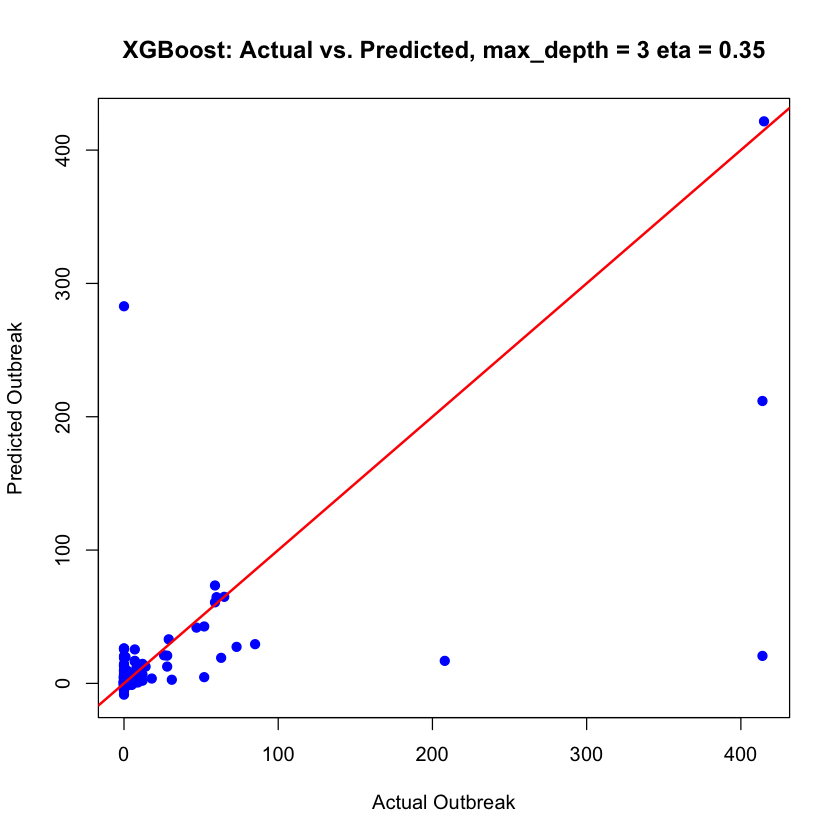

In [ ]:
results_xgb <- data.frame()
pred_plot_data_xgb <- list()

set.seed(100)
for(i in 1:nrow(param_grid)){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  xgb_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    X_fold_train <- as.matrix(fold_train[, names(fold_train) != "outbreak"])
    y_fold_train <- as.numeric(as.character(fold_train$outbreak))
    X_fold_test  <- as.matrix(fold_test[, names(fold_test) != "outbreak"])
    y_fold_test  <- as.numeric(as.character(fold_test$outbreak))

    dtrain_fold <- xgb.DMatrix(data = X_fold_train, label = y_fold_train)
    dtest_fold  <- xgb.DMatrix(data = X_fold_test, label = y_fold_test)

    model <- xgb.train(
      params = list(
        objective   = "reg:squarederror",
        eval_metric = "rmse",
        max_depth   = param_grid$max_depth[i],
        eta         = param_grid$eta[i]
      ),
      data    = dtrain_fold,
      nrounds = 500
    )

    predictions   <- predict(model, newdata = dtest_fold)
    actual_values <- fold_test$outbreak

    xgb_predictions <- rbind(xgb_predictions, data.frame(
      actual = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae, mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  combo_name <- paste(param_grid$max_depth[i], param_grid$eta[i], sep = "_")
  pred_plot_data_xgb[[combo_name]] <- xgb_predictions

  results_xgb <- rbind(results_xgb, data.frame(
    max_depth = param_grid$max_depth[i],
    eta       = param_grid$eta[i],
    RMSE      = mean(fold_rmse, na.rm = TRUE),
    MAE       = mean(fold_mae,  na.rm = TRUE),
    R2        = mean(fold_r2,   na.rm = TRUE)
  ))
}

best_xgb <- results_xgb[which.max(results_xgb$R2), ]
print(best_xgb)

best_combo <- paste(best_xgb$max_depth[1], best_xgb$eta[1], sep = "_")
best_plot_data_xgb <- pred_plot_data_xgb[[best_combo]]

plot(best_plot_data_xgb$actual, best_plot_data_xgb$predicted,
     main = paste(
       "XGBoost: Actual vs. Predicted, max_depth =",
       best_xgb$max_depth[1],
       "eta =",
       best_xgb$eta[1]
     ),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch = 19,
     col = "blue")

abline(0, 1, col = "red", lwd = 2)

### Parameter tuning for log

In [106]:
# For log transformations
set.seed(100)

# Recreate folds on transformed target
#strata <- ifelse(train$outbreak > 0, 1, 0)
folds <- createFolds(train$outbreak , k = 5, list = TRUE)

# Log transform outbreak
train$outbreak <- log10(train$outbreak + 1)

# PARAMETERS TO TUNE: 

# Default values: 
# minsplits: 20, minbuckets: minsplit/3, maxdepth: 30 
# ntrees: 500, mtrys: (# of features)/3, nodesize: 5, maxnode: none 
# learning_rate: 0.3, max_depth: 6, min_child_weight: 1, subsamble: 1, early_stopping: none 

# Base tree: 
minsplits  <- seq(20, 50, by = 5)       #  
minbuckets <- seq(10, 20, by = 5)       # min number of obervations that have to be in a node 
maxdepths <- seq(10, 30, by = 10)       # max depth of the tree

# Random Forest: 
ntrees <- seq(300, 700, by = 100)       # number of trees to create
mtrys <- seq(10, 60, by = 10)           # number of variables to consider
nodesizes <- seq(5, 20, by = 5)         # min number of obervations that have to be in a node 
maxnodes <- seq(5, 20, by = 5)          # maximum number of nodes in a given tree (minbuckets)

# Xgboost 
eta <- c(0.01, seq(0.05, 0.4, by = 0.05))  # learning rate of each tree
max_depth <- seq(3, 9, by = 3)             # max depth of any tree
min_child_weight <- seq(1, 5, by = 1)     # min nunmber of observations that have to be in a node (minbuckets)
subsample <- seq(0.4, 1, by = 0.1)         # samples a subsample of the total data for each tree
early_stopping <- seq(10, 30, by = 10)     # number of iterations where model stops training if there is marginal imporvement   


### Log regression with tuning for minsplit, minbucket, and cp

In [107]:
set.seed(100)
param_grid_tree <- expand.grid(minsplit  = minsplits,
                               minbucket = minbuckets,
                               maxdepth  = maxdepths)

results_log <- data.frame()

for(i in 1:nrow(param_grid_tree)){
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for(fold in folds){
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    mod <- rpart(outbreak ~ .,
                 data    = fold_train,
                 method  = "anova",
                 control = rpart.control(
                   cp        = -1,
                   minsplit  = param_grid_tree$minsplit[i],
                   minbucket = param_grid_tree$minbucket[i],
                   maxdepth = param_grid_tree$maxdepth[i]
                 ))

    cp_table <- mod$cptable
    opt_cp   <- as.numeric(cp_table[which.min(cp_table[, "xerror"]), "CP"])[1]
    pruned   <- prune(mod, cp = opt_cp)

    predictions   <- predict(pruned, newdata = fold_test)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_log <- rbind(results_log, data.frame(
    minsplit  = param_grid_tree$minsplit[i],
    minbucket = param_grid_tree$minbucket[i],
    maxdepth = param_grid_tree$maxdepth[i],
    RMSE      = mean(fold_rmse),
    MAE       = mean(fold_mae),
    R2        = mean(fold_r2)
  ))
}

best_log <- results_log[which.max(results_log$R2), ]
print(results_log)
print(best_log)

# 10 fold r2: -0.2800967
# 5 fold r2:  -0.05742354


   minsplit minbucket maxdepth      RMSE       MAE        R2
1        20        10       10 0.3377364 0.1815038 -1.417017
2        25        10       10 0.3420380 0.1613339 -1.784991
3        30        10       10 0.3355896 0.1755707 -1.404740
4        35        10       10 0.3375388 0.1842388 -1.415875
5        40        10       10 0.3231001 0.1661993 -1.584362
6        45        10       10 0.3053513 0.1577981 -1.473759
7        50        10       10 0.2975668 0.1667726 -1.161522
8        20        15       10 0.3066343 0.1531667 -1.519964
9        25        15       10 0.3214055 0.1748442 -1.303335
10       30        15       10 0.3061729 0.1592951 -1.235149
11       35        15       10 0.2993705 0.1508729 -1.459342
12       40        15       10 0.3128609 0.1545829 -1.520967
13       45        15       10 0.3124357 0.1562093 -1.510225
14       50        15       10 0.3153397 0.1700569 -2.519353
15       20        20       10 0.3058742 0.1520540 -1.202212
16       25        20   

### Random Forest with log and new parameters

In [108]:
set.seed(100)
param_grid_rf <- expand.grid(ntree    = ntrees,
                             mtry     = mtrys,
                             nodesize = nodesizes,
                             maxnodes = maxnodes)

results_rf_log <- data.frame()

for(i in 1:nrow(param_grid_rf)){
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for(fold in folds){
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    rf <- randomForest(outbreak ~ .,
                       data     = fold_train,
                       ntree    = param_grid_rf$ntree[i],
                       mtry     = param_grid_rf$mtry[i],
                       nodesize = param_grid_rf$nodesize[i],
                       maxnodes = param_grid_rf$maxnodes[i])

    predictions   <- predict(rf, newdata = fold_test)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))
    
    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_rf_log <- rbind(results_rf_log, data.frame(
    ntree    = param_grid_rf$ntree[i],
    mtry     = param_grid_rf$mtry[i],
    nodesize = param_grid_rf$nodesize[i],
    maxnodes = param_grid_rf$maxnodes[i],
    RMSE     = mean(fold_rmse),
    MAE      = mean(fold_mae),
    R2       = mean(fold_r2)
  ))
}

best_rf_log <- results_rf_log[which.max(results_rf_log$R2), ]
print(best_rf_log)
# 10 fold r2: -0.5256998
# 5 fold r2: 0.09608646

   ntree mtry nodesize maxnodes      RMSE       MAE        R2
88   500   60       15        5 0.3027604 0.1582429 -2.515822


### Xgboost with new parameters

In [109]:
set.seed(100)
param_grid_xgb <- expand.grid(
  eta               = eta,
  max_depth         = max_depth,
  min_child_weight  = min_child_weight,
  subsample         = subsample,
  early_stopping_rounds    = early_stopping
)

results_xgb_log <- data.frame()

for (i in 1:nrow(param_grid_xgb)) {
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for (fold in folds) {
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    dtrain <- xgb.DMatrix(
      data  = as.matrix(fold_train[, !names(fold_train) %in% "outbreak"]),
      label = fold_train$outbreak
    )
    dtest <- xgb.DMatrix(
      data  = as.matrix(fold_test[, !names(fold_test) %in% "outbreak"]),
      label = fold_test$outbreak
    )

    xgb_model <- xgb.train(
      params = list(
        objective        = "reg:squarederror",
        eta              = param_grid_xgb$eta[i],
        max_depth        = param_grid_xgb$max_depth[i],
        min_child_weight = param_grid_xgb$min_child_weight[i],
        subsample        = param_grid_xgb$subsample[i],
        early_stopping_rounds = param_grid_xgb$early_stopping_rounds[i]
      ),
      data       = dtrain,
      nrounds    = 500,
      evals  = list(eval = dtest, train = dtrain),
      early_stopping_rounds = param_grid_xgb$early_stopping[i],
      verbose    = 0
    )

    predictions   <- predict(xgb_model, newdata = dtest)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_xgb_log <- rbind(results_xgb_log, data.frame(
    eta              = param_grid_xgb$eta[i],
    max_depth        = param_grid_xgb$max_depth[i],
    min_child_weight = param_grid_xgb$min_child_weight[i],
    subsample        = param_grid_xgb$subsample[i],
    early_stopping   = param_grid_xgb$early_stopping[i],
    RMSE             = mean(fold_rmse),
    MAE              = mean(fold_mae),
    R2               = mean(fold_r2)
  ))
}

best_xgb_log <- results_xgb_log[which.max(results_xgb_log$R2), ]
print(best_xgb_log)

# 10 fold r2: 
# 5 fold r2: 0.06283211

      eta max_depth min_child_weight subsample early_stopping      RMSE
2173 0.15         6                1       0.6             30 0.3012168
           MAE        R2
2173 0.1619706 -1.041992


### Save best models

In [110]:
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE)
test           <- read_csv("data/created/test_clean.csv",     show_col_types = FALSE)

In [111]:
# Regression Tree with best params
set.seed(100)
dtree_model_final <- rpart(
  outbreak ~ .,
  data    = train,
  method  = "anova",
  control = rpart.control(
    cp        = -1,
    maxdepth  = best_log$maxdepth,
    minsplit  = best_log$minsplit,
    minbucket = best_log$minbucket
  )
)
opt_cp        <- as.numeric(dtree_model_final$cptable[which.min(dtree_model_final$cptable[, "xerror"]), "CP"])[1]
dtree_model_final <- prune(dtree_model_final, cp = opt_cp)

pred_dt   <- predict(dtree_model_final, newdata = test)
actual    <- log10(test$outbreak + 1)
dt_rmse   <- sqrt(mean((actual - pred_dt)^2))
dt_mae    <- mean(abs(actual - pred_dt))
dt_r2     <- 1 - sum((actual - pred_dt)^2) / sum((actual - mean(actual))^2)
cat("Final Regression Tree | RMSE:", round(dt_rmse,4), "MAE:", round(dt_mae,4), "R2:", round(dt_r2,4), "\n")

saveRDS(dtree_model_final, "data/results/models/dtree_reg_svi.rds")

Final Regression Tree | RMSE: 0.3615 MAE: 0.1723 R2: 0.1169 


In [112]:
# Random Forest with best params 
set.seed(100)
rforest_model_final <- randomForest(
  outbreak ~ .,
  data     = train,
  ntree    = best_rf_log$ntree,
  mtry     = best_rf_log$mtry,
  nodesize = best_rf_log$nodesize,
  maxnodes = best_rf_log$maxnodes,
  importance = TRUE
)

pred_rf   <- predict(rforest_model_final, newdata = test)
rf_rmse   <- sqrt(mean((actual - pred_rf)^2))
rf_mae    <- mean(abs(actual - pred_rf))
rf_r2     <- 1 - sum((actual - pred_rf)^2) / sum((actual - mean(actual))^2)
cat("Final Random Forest   | RMSE:", round(rf_rmse,4), "MAE:", round(rf_mae,4), "R2:", round(rf_r2,4), "\n")

saveRDS(rforest_model_final, "data/results/models/rforest_reg_svi.rds")

Final Random Forest   | RMSE: 0.3571 MAE: 0.1759 R2: 0.1384 


In [113]:
# XGBoost with best params
set.seed(100)
X_train_final <- as.matrix(train[, names(train) != "outbreak"])
y_train_final <- as.numeric(train$outbreak)
X_test_final  <- as.matrix(test[, names(test) != "outbreak"])
y_test_final  <- as.numeric(log10(test$outbreak + 1))

dtrain_final  <- xgb.DMatrix(data = X_train_final, label = y_train_final)
dtest_final   <- xgb.DMatrix(data = X_test_final,  label = y_test_final)

boost_model_final <- xgb.train(
  params = list(
    objective        = "reg:squarederror",
    eta              = best_xgb_log$eta,
    max_depth        = best_xgb_log$max_depth,
    min_child_weight = best_xgb_log$min_child_weight,
    subsample        = best_xgb_log$subsample
  ),
  data    = dtrain_final,
  nrounds = 500,
  verbose = 0
)

pred_xgb  <- predict(boost_model_final, dtest_final)
xgb_rmse  <- sqrt(mean((y_test_final - pred_xgb)^2))
xgb_mae   <- mean(abs(y_test_final - pred_xgb))
xgb_r2    <- 1 - sum((y_test_final - pred_xgb)^2) / sum((y_test_final - mean(y_test_final))^2)
cat("Final XGBoost         | RMSE:", round(xgb_rmse,4), "MAE:", round(xgb_mae,4), "R2:", round(xgb_r2,4), "\n")

saveRDS(boost_model_final, "data/results/models/xgb_reg_svi.rds")


Final XGBoost         | RMSE: 0.354 MAE: 0.1785 R2: 0.1531 


In [114]:
importance_df <- data.frame(
  Variable = names(dtree_model_final$variable.importance),
  Importance = dtree_model_final$variable.importance,
  row.names = NULL
)


write.csv(importance_df, "data/results/important_vars_dtree_reg.csv")
write.csv(importance(rforest_model_final), "data/results/important_vars_rforest_reg.csv")
write.csv(xgb.importance(model = boost_model_final), "data/results/important_vars_xgboost_reg.csv")
